# Load Test Analysis

This notebook analyses Locust CSV outputs only.

It covers:
- summary comparison across load levels
- time-series response-time and throughput behaviour
- failure and exception summaries
- report-ready tables for load-testing outputs

All figures are saved into `results/figures/`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts").exists() and (REPO_ROOT.parent / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.analysis_helpers import (
    available_locust_prefixes,
    build_figure_filename,
    ensure_figures_dir,
    load_locust_comparison,
    load_locust_result_set,
    round_numeric_dataframe,
    save_and_display_figure,
    save_figure,
)

results_dir = REPO_ROOT / "results"
figures_dir = ensure_figures_dir(results_dir / "figures")

# Optionally set a subset of prefixes to analyse. Example: ["locust_5_users", "locust_10_users"]
selected_prefixes = None

detected_prefixes = available_locust_prefixes(results_dir=results_dir)
if selected_prefixes:
    detected_prefixes = [prefix for prefix in detected_prefixes if prefix in selected_prefixes]

if not detected_prefixes:
    raise FileNotFoundError("No Locust stats CSV files were found in results/.")

print("Detected Locust runs:")
for prefix in detected_prefixes:
    print(f"- {prefix}")
print(f"Figures directory: {figures_dir}")


def axis_note(ax, title: str, message: str) -> None:
    ax.set_title(title)
    ax.text(0.5, 0.5, message, ha="center", va="center", wrap=True)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def signature_payload(chart_key: str, data: object, extra: object = None) -> dict:
    payload = {"chart_key": chart_key, "data": data}
    if extra is not None:
        payload["extra"] = extra
    return payload


Detected Locust runs:
- locust_5_users
- locust_10_users
- locust_20_users
Figures directory: C:\Users\Emman\OneDrive\Documents\GitHub\PartD_GroupProject\results\figures


## Summary Comparison Across Load Levels

This section builds a per-load summary table and compares response-time, throughput, and failure behaviour across available Locust runs.

,filename,prefix,user_count,request_count,failure_count,average_response_time,median_response_time,requests_per_second,failures_per_second,failure_rate
0,locust_5_users_stats.csv,locust_5_users,5,159.0,8.0,7245.329,5800.0,0.534,0.027,0.050
1,locust_10_users_stats.csv,locust_10_users,10,312.0,31.0,7473.401,6400.0,1.045,0.104,0.099
2,locust_20_users_stats.csv,locust_20_users,20,645.0,128.0,7002.607,6300.0,2.167,0.430,0.198


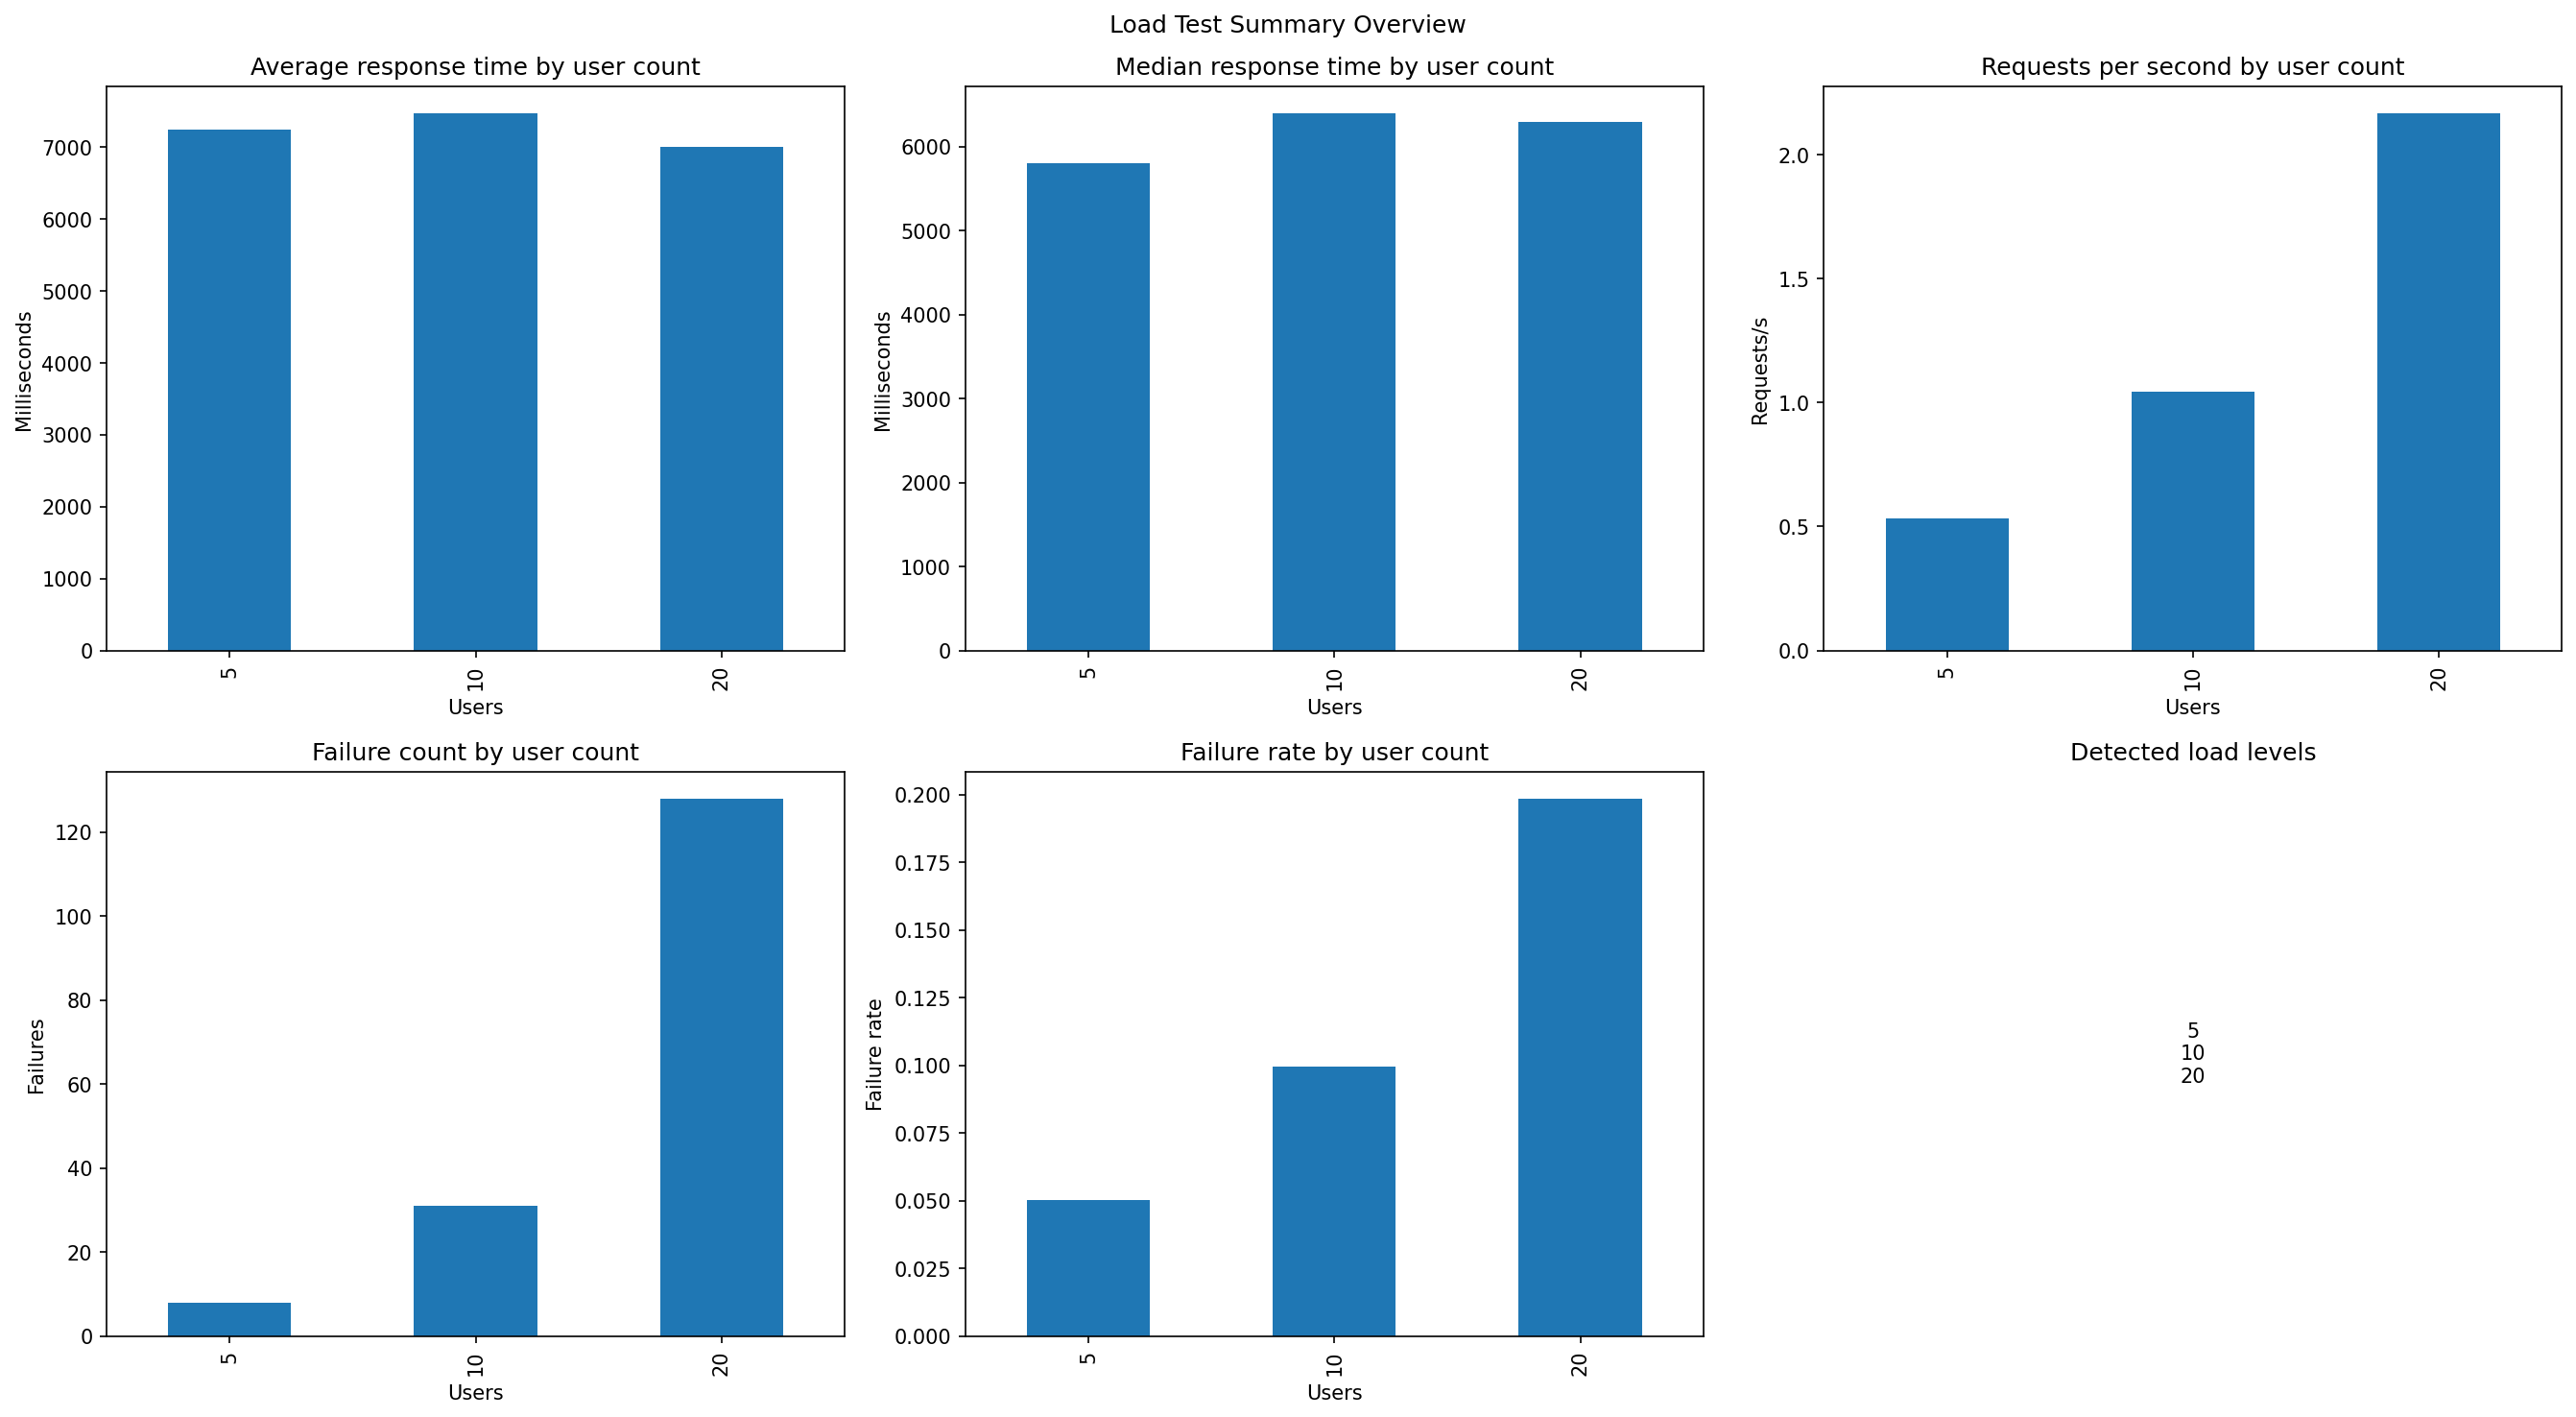

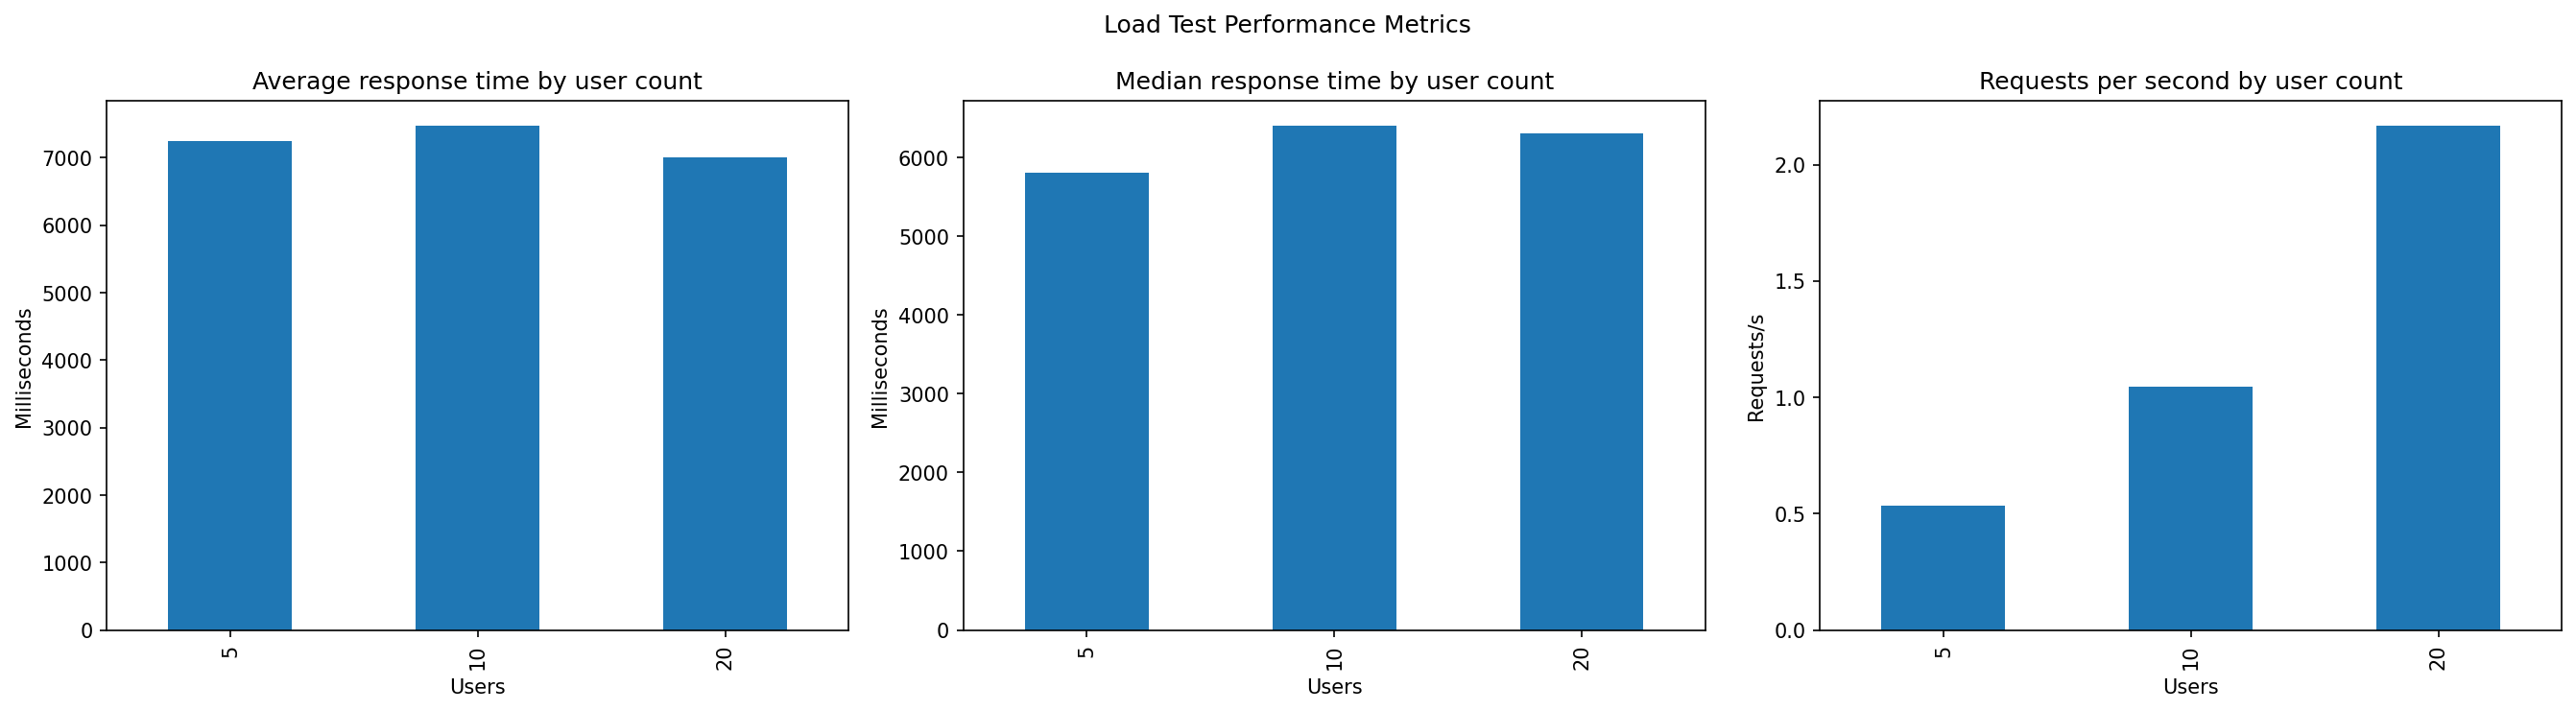

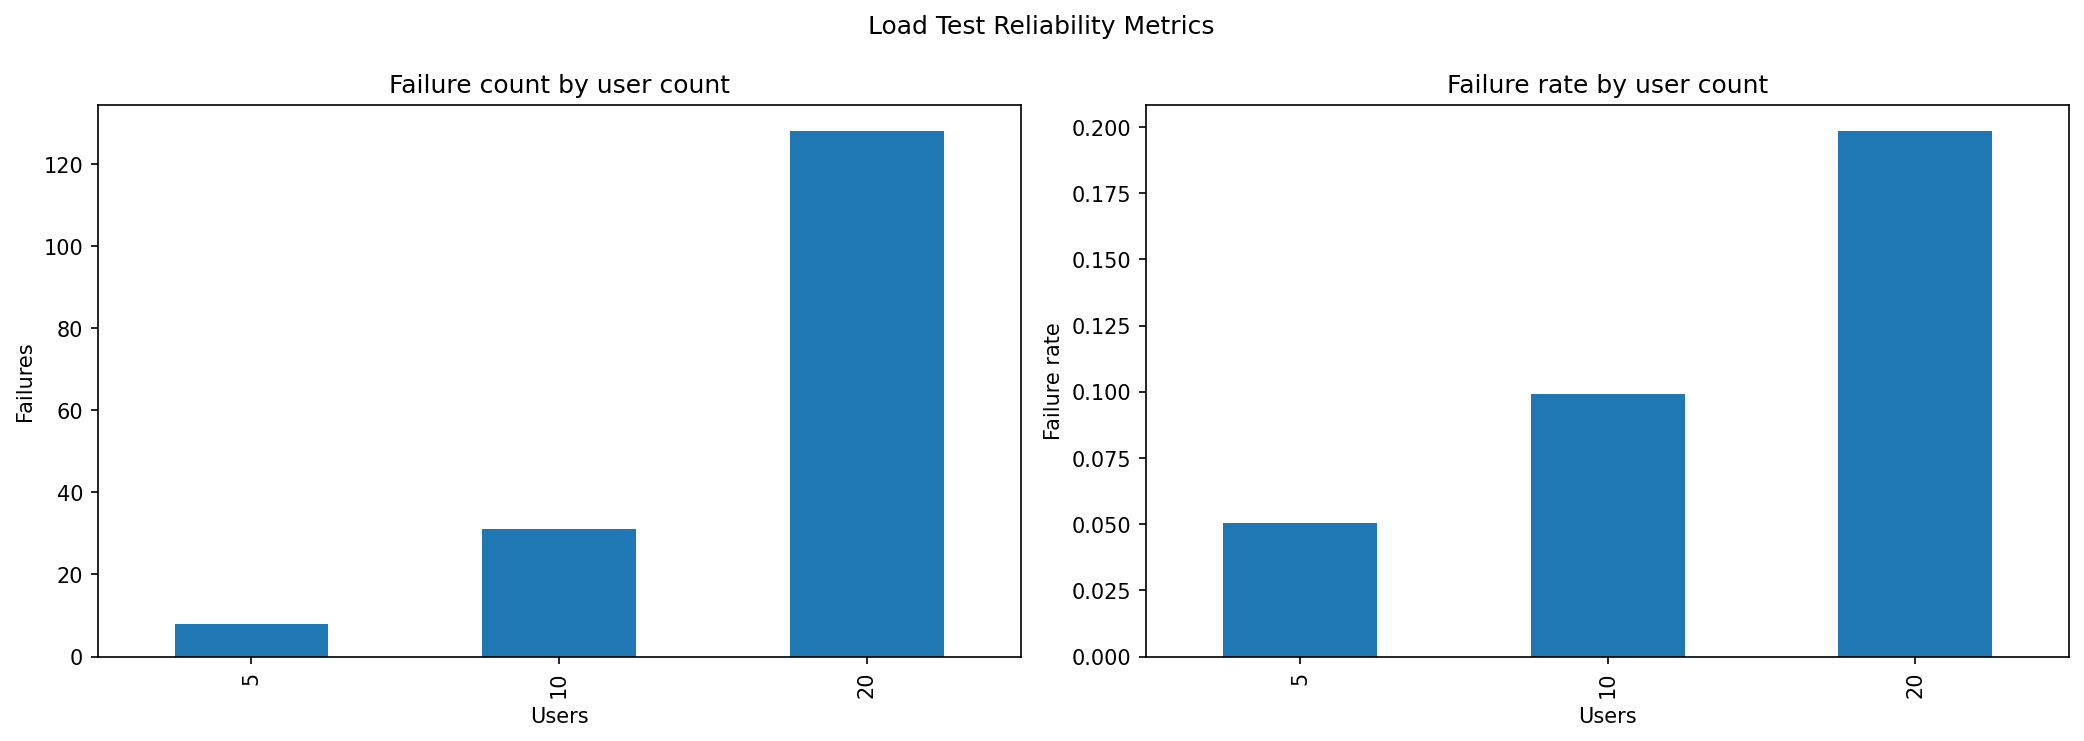

In [2]:
summary_df = load_locust_comparison(results_dir=results_dir, prefixes=detected_prefixes)
display(round_numeric_dataframe(summary_df))

if summary_df.empty:
    print("No Locust summary rows were available for plotting.")
else:
    plot_df = summary_df.sort_values("user_count").set_index("user_count")
    chart_specs = [
        ("average_response_time", "Average response time by user count", "Milliseconds", "locust_average_response_time_by_users.png"),
        ("median_response_time", "Median response time by user count", "Milliseconds", "locust_median_response_time_by_users.png"),
        ("requests_per_second", "Requests per second by user count", "Requests/s", "locust_requests_per_second_by_users.png"),
        ("failure_count", "Failure count by user count", "Failures", "locust_failure_count_by_users.png"),
    ]
    for column, title, ylabel, filename in chart_specs:
        if column not in plot_df.columns:
            print(f"Skipping chart because '{column}' is missing.")
            continue
        values = pd.to_numeric(plot_df[column], errors="coerce").dropna()
        if values.empty:
            print(f"Skipping chart because '{column}' had no numeric values.")
            continue
        fig, ax = plt.subplots()
        values.plot(kind="bar", ax=ax)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Users")
        save_figure(fig, filename, output_dir=figures_dir, signature_parts=signature_payload(f"locust_summary_{column}", values.to_dict()))

    if "failure_rate" in plot_df.columns:
        values = pd.to_numeric(plot_df["failure_rate"], errors="coerce").dropna()
        if not values.empty:
            fig, ax = plt.subplots()
            values.plot(kind="bar", ax=ax)
            ax.set_title("Failure rate by user count")
            ax.set_ylabel("Failure rate")
            ax.set_xlabel("Users")
            save_figure(fig, "locust_failure_rate_by_users.png", output_dir=figures_dir, signature_parts=signature_payload("locust_summary_failure_rate", values.to_dict()))

    overview_fig, overview_axes = plt.subplots(2, 3, figsize=(18, 10))
    overview_specs = [
        (overview_axes[0, 0], "average_response_time", "Average response time by user count", "Milliseconds"),
        (overview_axes[0, 1], "median_response_time", "Median response time by user count", "Milliseconds"),
        (overview_axes[0, 2], "requests_per_second", "Requests per second by user count", "Requests/s"),
        (overview_axes[1, 0], "failure_count", "Failure count by user count", "Failures"),
        (overview_axes[1, 1], "failure_rate", "Failure rate by user count", "Failure rate"),
    ]
    for axis, column, title, ylabel in overview_specs:
        if column in plot_df.columns:
            values = pd.to_numeric(plot_df[column], errors="coerce").dropna()
            if not values.empty:
                values.plot(kind="bar", ax=axis)
                axis.set_title(title)
                axis.set_ylabel(ylabel)
                axis.set_xlabel("Users")
                continue
        axis_note(axis, title, "No numeric values were available.")
    axis_note(overview_axes[1, 2], "Detected load levels", "\n".join(str(value) for value in plot_df.index.tolist()))

    overview_fig.suptitle("Load Test Summary Overview")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename("locust", "summary", "overview"), output_dir=figures_dir, signature_parts=signature_payload("locust_summary_overview", plot_df.reset_index()))

    performance_fig, performance_axes = plt.subplots(1, 3, figsize=(18, 5))
    performance_specs = [
        (performance_axes[0], "average_response_time", "Average response time by user count", "Milliseconds"),
        (performance_axes[1], "median_response_time", "Median response time by user count", "Milliseconds"),
        (performance_axes[2], "requests_per_second", "Requests per second by user count", "Requests/s"),
    ]
    for axis, column, title, ylabel in performance_specs:
        if column in plot_df.columns:
            values = pd.to_numeric(plot_df[column], errors="coerce").dropna()
            if not values.empty:
                values.plot(kind="bar", ax=axis)
                axis.set_title(title)
                axis.set_ylabel(ylabel)
                axis.set_xlabel("Users")
                continue
        axis_note(axis, title, "No numeric values were available.")

    performance_fig.suptitle("Load Test Performance Metrics")
    performance_fig.tight_layout()
    save_and_display_figure(performance_fig, build_figure_filename("locust", "summary", "grouped_performance"), output_dir=figures_dir, signature_parts=signature_payload("locust_summary_grouped_performance", plot_df.reset_index()))

    reliability_fig, reliability_axes = plt.subplots(1, 2, figsize=(14, 5))
    reliability_specs = [
        (reliability_axes[0], "failure_count", "Failure count by user count", "Failures"),
        (reliability_axes[1], "failure_rate", "Failure rate by user count", "Failure rate"),
    ]
    for axis, column, title, ylabel in reliability_specs:
        if column in plot_df.columns:
            values = pd.to_numeric(plot_df[column], errors="coerce").dropna()
            if not values.empty:
                values.plot(kind="bar", ax=axis)
                axis.set_title(title)
                axis.set_ylabel(ylabel)
                axis.set_xlabel("Users")
                continue
        axis_note(axis, title, "No numeric values were available.")

    reliability_fig.suptitle("Load Test Reliability Metrics")
    reliability_fig.tight_layout()
    save_and_display_figure(reliability_fig, build_figure_filename("locust", "summary", "grouped_reliability"), output_dir=figures_dir, signature_parts=signature_payload("locust_summary_grouped_reliability", plot_df.reset_index()))


## Time-Series Load Behaviour

This section uses `*_stats_history.csv` files to visualise how average response time, requests/s, and failures/s change over time.

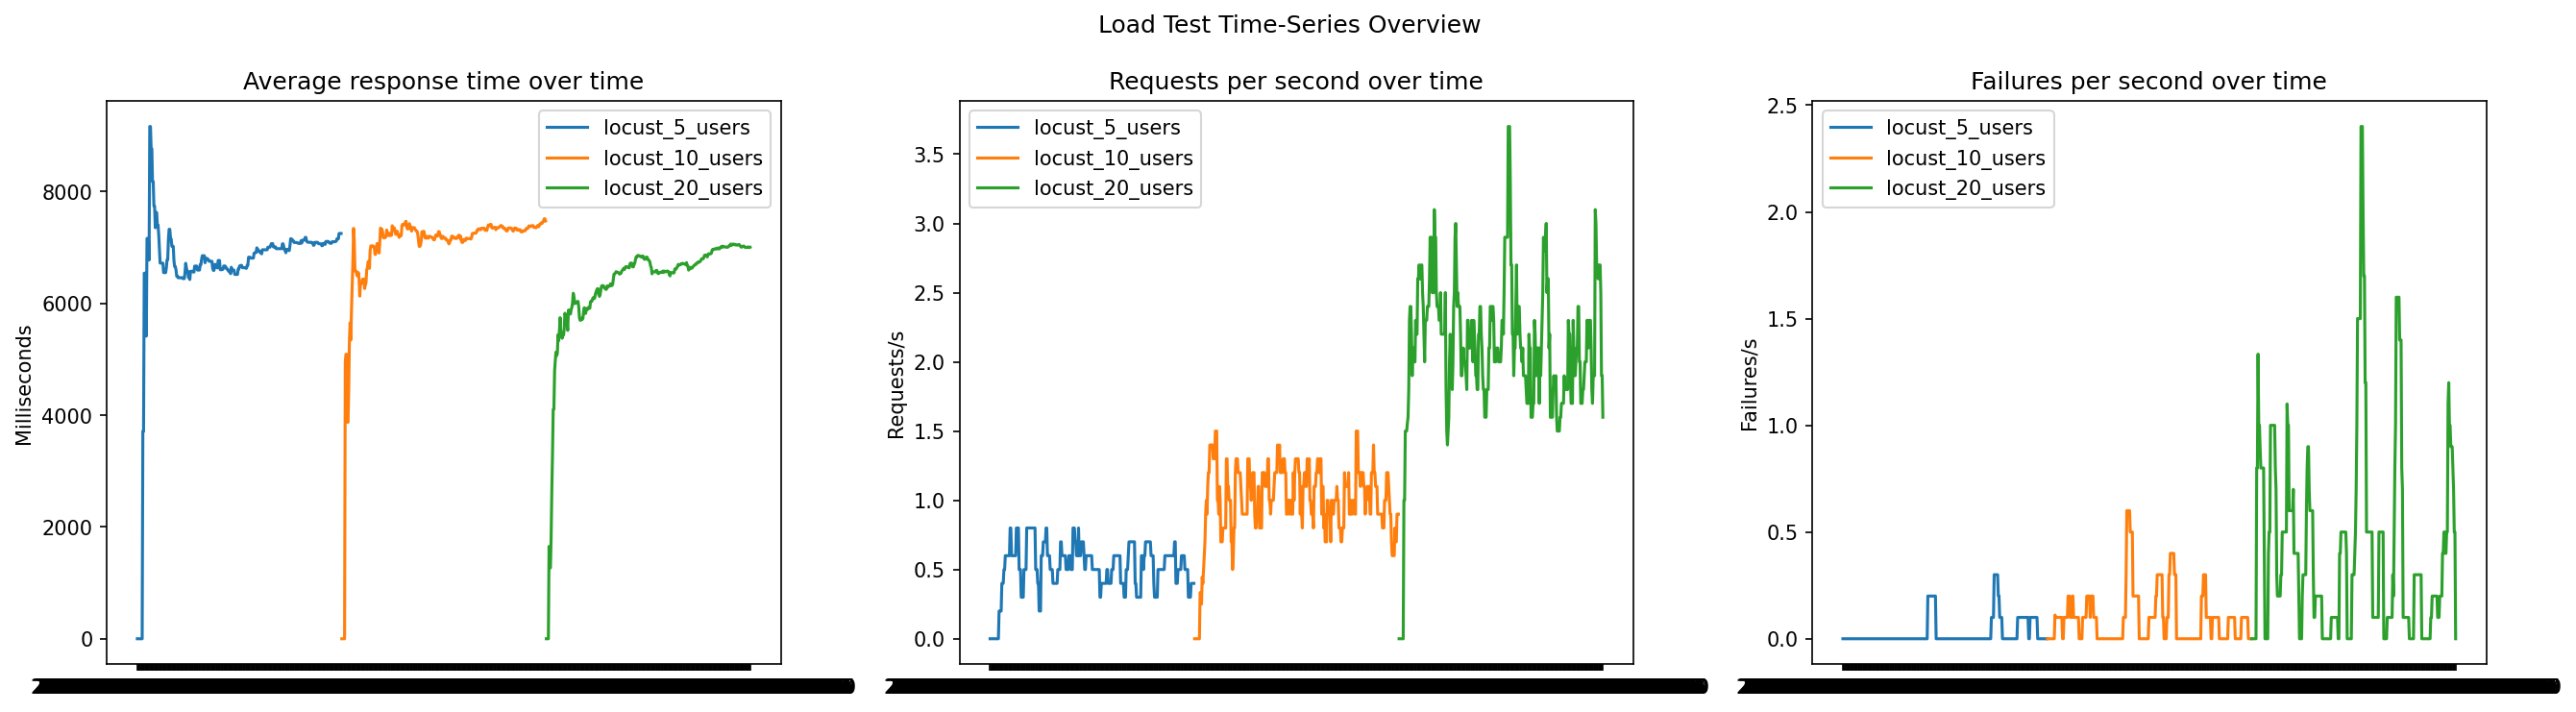

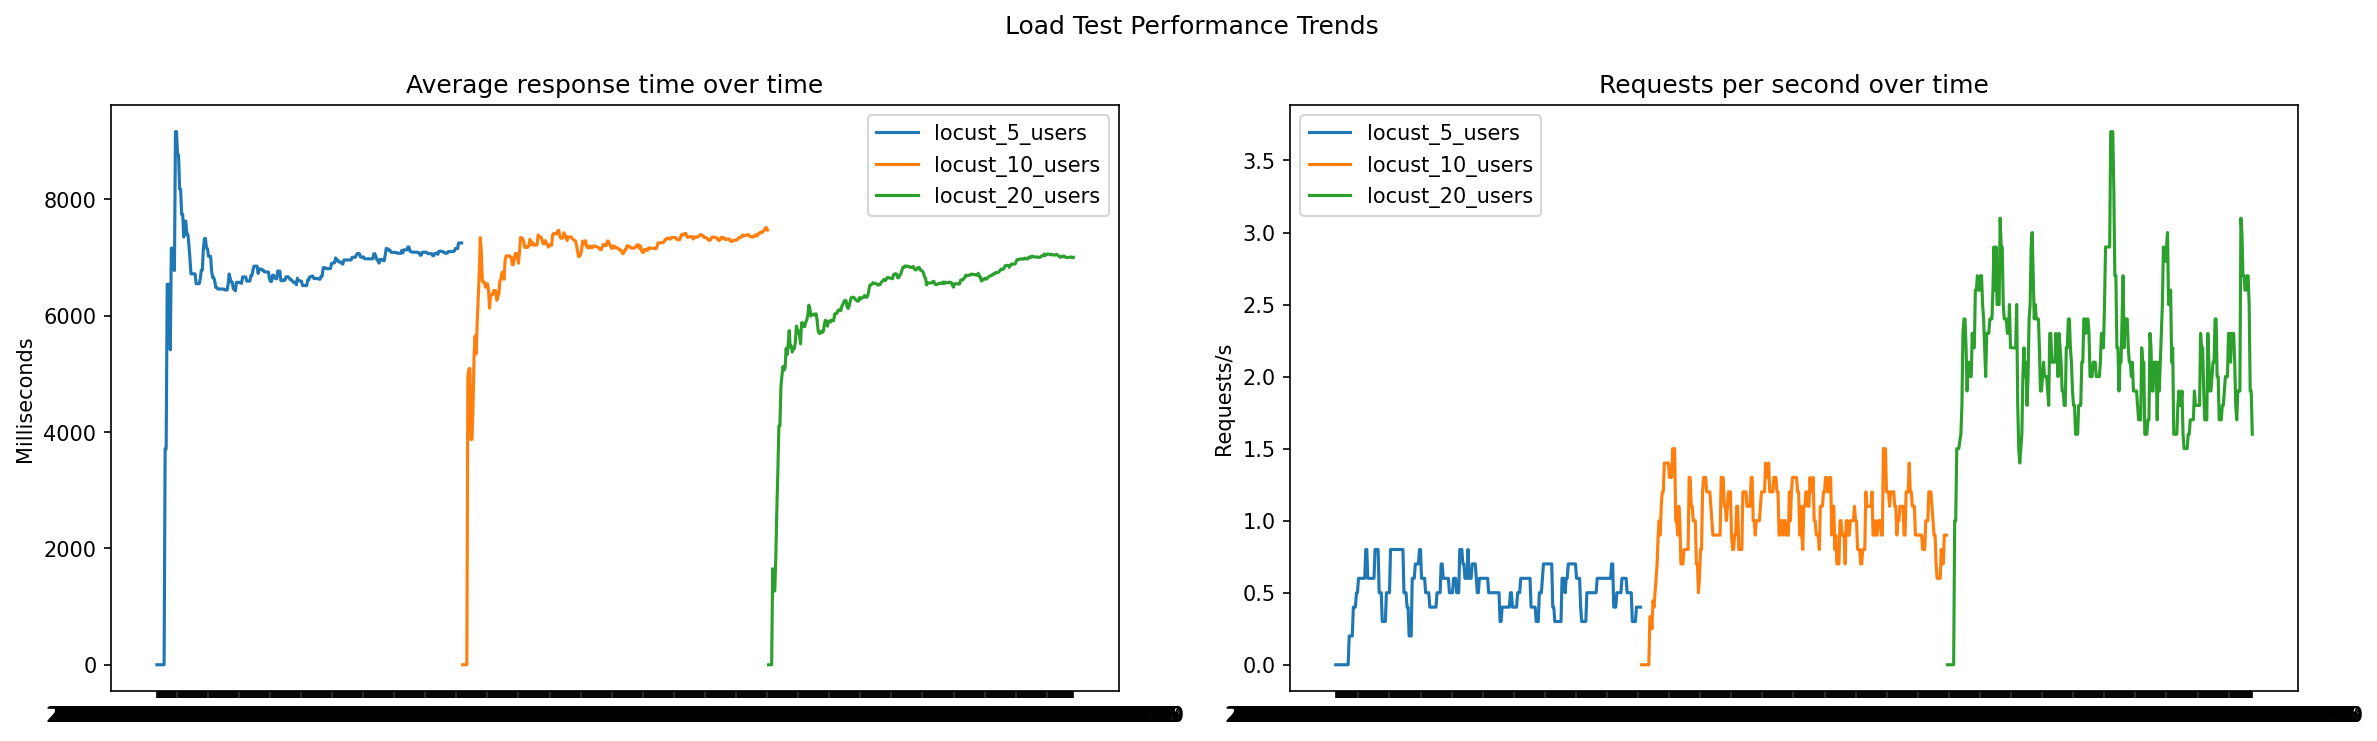

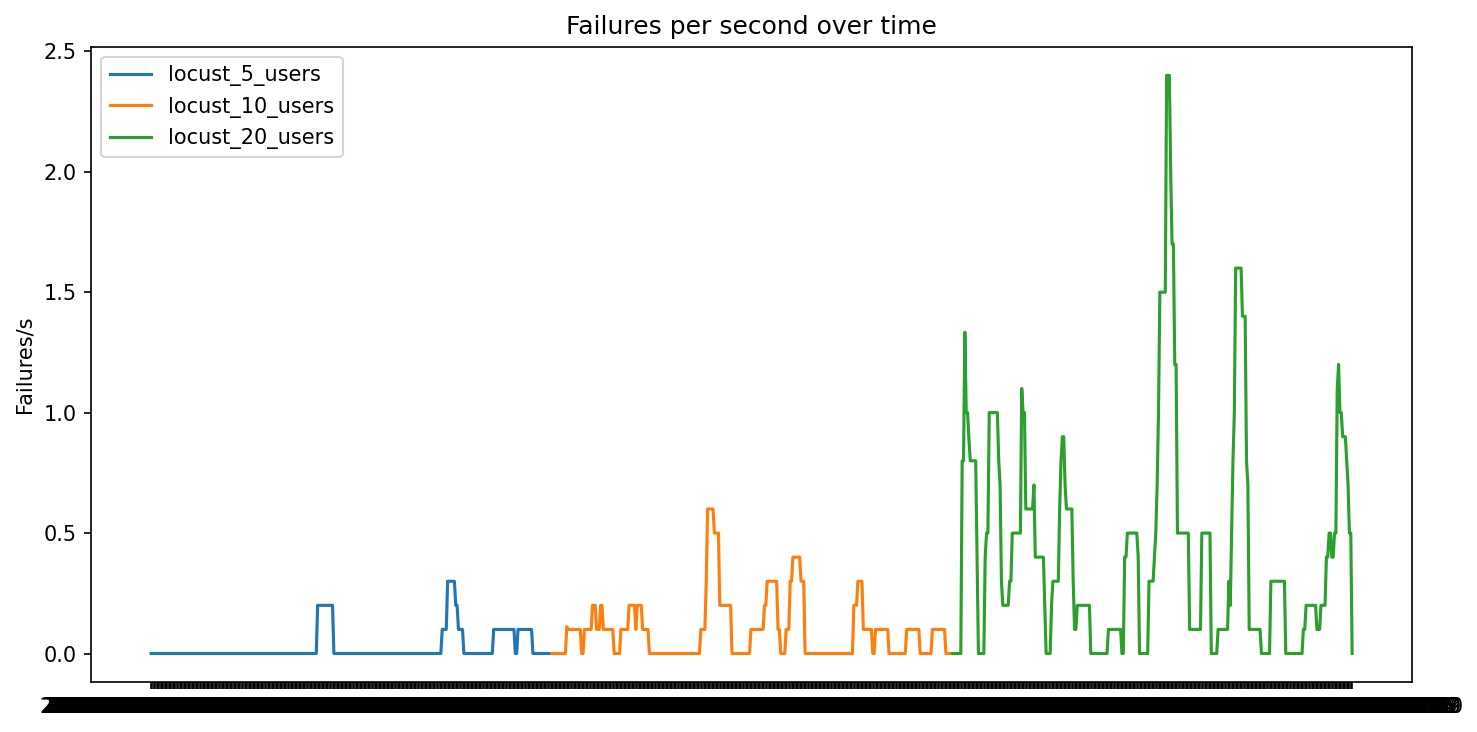

In [3]:
history_specs = [
    ("Total Average Response Time", "Average response time over time", "Milliseconds", "locust_history_average_response_time.png"),
    ("Requests/s", "Requests per second over time", "Requests/s", "locust_history_requests_per_second.png"),
    ("Failures/s", "Failures per second over time", "Failures/s", "locust_history_failures_per_second.png"),
]

history_payloads = {}
for column, title, ylabel, filename in history_specs:
    fig, ax = plt.subplots()
    plotted = False
    series_payload = {}
    for prefix in detected_prefixes:
        result_set = load_locust_result_set(prefix, results_dir=results_dir)
        history_df = result_set.get("stats_history")
        if history_df is None or history_df.empty or column not in history_df.columns:
            continue

        working = history_df.copy()
        if "Name" in working.columns:
            working = working[working["Name"].astype(str).str.strip() == "Aggregated"]
        if working.empty:
            continue

        working[column] = pd.to_numeric(working[column], errors="coerce")
        if "Timestamp" in working.columns:
            x_values = pd.to_datetime(pd.to_numeric(working["Timestamp"], errors="coerce"), unit="s", errors="coerce")
        else:
            x_values = pd.RangeIndex(start=0, stop=len(working), step=1)

        mask = working[column].notna()
        if not mask.any():
            continue

        x_plot = list(x_values[mask])
        y_plot = working.loc[mask, column].tolist()
        ax.plot(x_plot, y_plot, label=prefix)
        series_payload[prefix] = {"x": [str(value) for value in x_plot], "y": [float(value) for value in y_plot]}
        plotted = True

    if not plotted:
        plt.close(fig)
        print(f"Skipping time-series chart because '{column}' was unavailable across runs.")
        continue

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    history_payloads[column] = {"title": title, "ylabel": ylabel, "series": series_payload}
    save_figure(fig, filename, output_dir=figures_dir, signature_parts=signature_payload(f"locust_history_{column}", history_payloads[column]))

if not history_payloads:
    print("No time-series charts were available to display.")
else:
    overview_fig, overview_axes = plt.subplots(1, 3, figsize=(18, 5))
    for axis, (column, title, _, _) in zip(overview_axes, history_specs):
        payload = history_payloads.get(column)
        if payload is None:
            axis_note(axis, title, "No data was available for this metric.")
            continue
        for prefix, series in payload["series"].items():
            axis.plot(series["x"], series["y"], label=prefix)
        axis.set_title(payload["title"])
        axis.set_ylabel(payload["ylabel"])
        axis.legend()
    overview_fig.suptitle("Load Test Time-Series Overview")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename("locust", "history", "overview"), output_dir=figures_dir, signature_parts=signature_payload("locust_history_overview", history_payloads))

    performance_fig, performance_axes = plt.subplots(1, 2, figsize=(16, 5))
    for axis, column in zip(performance_axes, ["Total Average Response Time", "Requests/s"]):
        payload = history_payloads.get(column)
        title = payload["title"] if payload else column
        if payload is None:
            axis_note(axis, title, "No data was available for this metric.")
            continue
        for prefix, series in payload["series"].items():
            axis.plot(series["x"], series["y"], label=prefix)
        axis.set_title(payload["title"])
        axis.set_ylabel(payload["ylabel"])
        axis.legend()
    performance_fig.suptitle("Load Test Performance Trends")
    performance_fig.tight_layout()
    save_and_display_figure(performance_fig, build_figure_filename("locust", "history", "grouped_performance"), output_dir=figures_dir, signature_parts=signature_payload("locust_history_grouped_performance", {key: value for key, value in history_payloads.items() if key in {"Total Average Response Time", "Requests/s"}}))

    failures_payload = history_payloads.get("Failures/s")
    if failures_payload is not None:
        failures_fig, failures_ax = plt.subplots(figsize=(10, 5))
        for prefix, series in failures_payload["series"].items():
            failures_ax.plot(series["x"], series["y"], label=prefix)
        failures_ax.set_title(failures_payload["title"])
        failures_ax.set_ylabel(failures_payload["ylabel"])
        failures_ax.legend()
        failures_fig.tight_layout()
        save_and_display_figure(failures_fig, build_figure_filename("locust", "history", "grouped_failures"), output_dir=figures_dir, signature_parts=signature_payload("locust_history_grouped_failures", failures_payload))


## Failure and Exception Analysis

This section summarises failure totals and combines exception records across load levels when the corresponding CSV files are present.

,prefix,user_count,failure_total
0,locust_5_users,5,8
1,locust_10_users,10,31
2,locust_20_users,20,128


No exception rows were present in the detected Locust outputs.


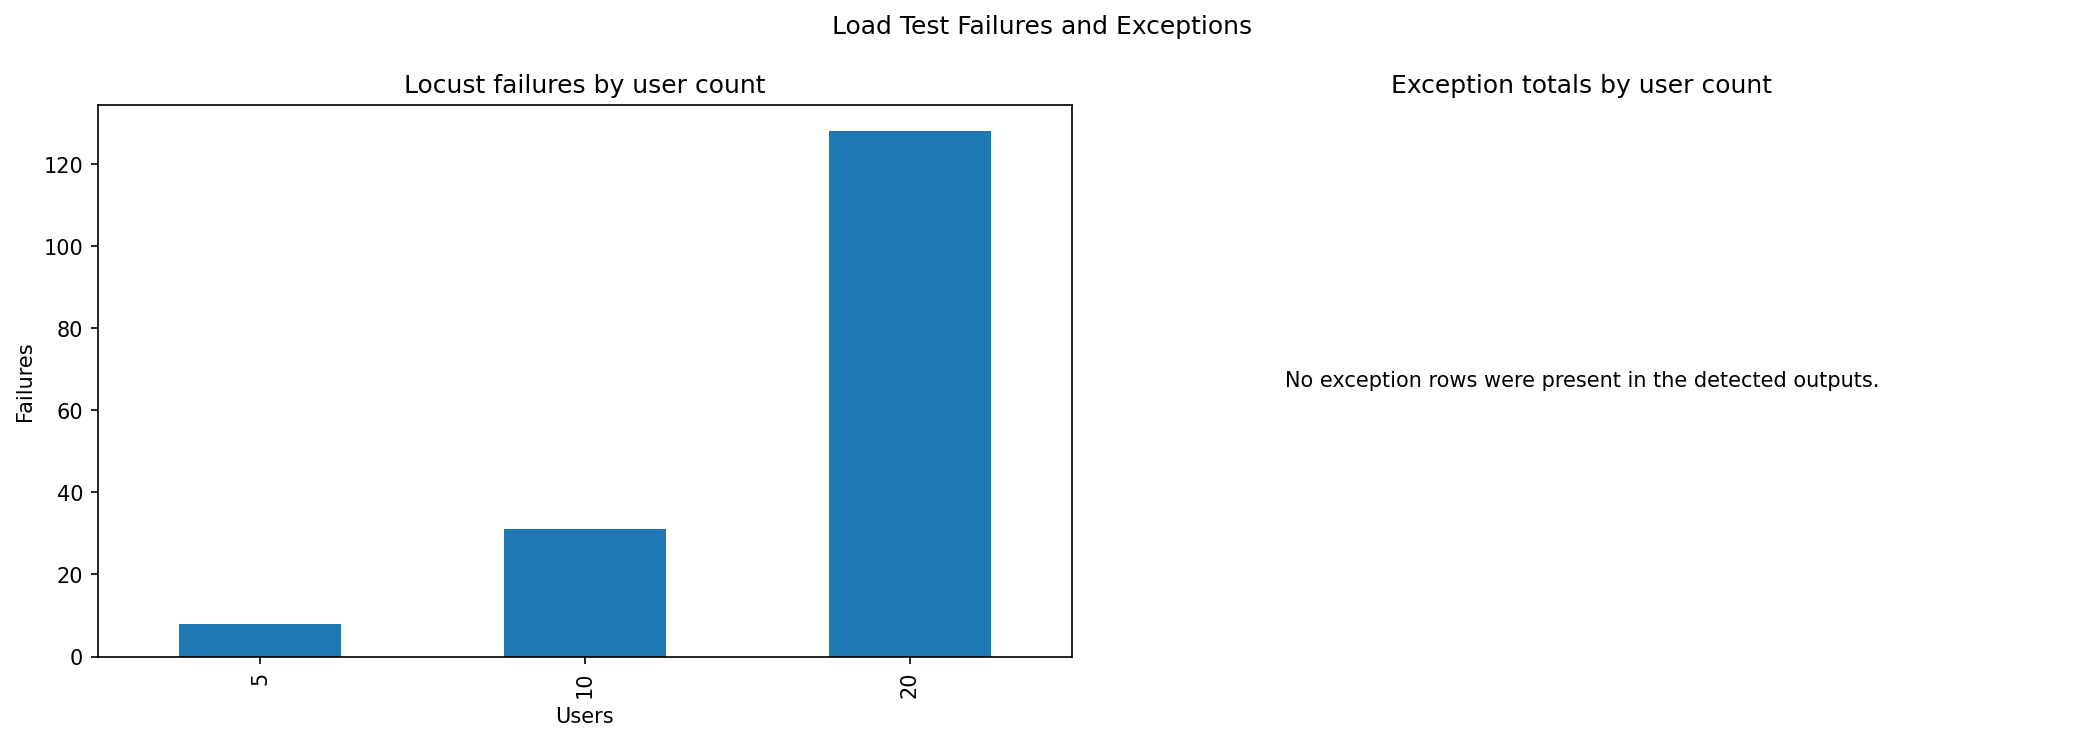

In [4]:
failure_rows = []
exception_frames = []

for prefix in detected_prefixes:
    result_set = load_locust_result_set(prefix, results_dir=results_dir)
    failures_df = result_set.get("failures")
    exceptions_df = result_set.get("exceptions")

    failure_total = 0.0
    if failures_df is not None and not failures_df.empty and "Occurrences" in failures_df.columns:
        failure_total = pd.to_numeric(failures_df["Occurrences"], errors="coerce").fillna(0).sum()

    failure_rows.append({"prefix": prefix, "user_count": result_set.get("user_count"), "failure_total": failure_total})

    if exceptions_df is not None and not exceptions_df.empty:
        frame = exceptions_df.copy()
        frame["prefix"] = prefix
        frame["user_count"] = result_set.get("user_count")
        exception_frames.append(frame)

failure_summary_df = pd.DataFrame(failure_rows).sort_values("user_count")
display(round_numeric_dataframe(failure_summary_df))

if not failure_summary_df.empty:
    fig, ax = plt.subplots()
    failure_summary_df.set_index("user_count")["failure_total"].plot(kind="bar", ax=ax)
    ax.set_title("Locust failures by user count")
    ax.set_ylabel("Failures")
    ax.set_xlabel("Users")
    save_figure(fig, "locust_failures_by_users.png", output_dir=figures_dir, signature_parts=signature_payload("locust_failure_totals", failure_summary_df))

if exception_frames:
    combined_exceptions = pd.concat(exception_frames, ignore_index=True)
    exception_summary = (
        combined_exceptions.groupby(["user_count", "Message"], dropna=False)
        .agg(total_count=("Count", "sum"))
        .reset_index()
        .sort_values(["user_count", "total_count"], ascending=[True, False])
    )
    display(exception_summary)
else:
    exception_summary = pd.DataFrame()
    print("No exception rows were present in the detected Locust outputs.")

if not failure_summary_df.empty:
    overview_fig, overview_axes = plt.subplots(1, 2, figsize=(14, 5))
    failure_summary_df.set_index("user_count")["failure_total"].plot(kind="bar", ax=overview_axes[0])
    overview_axes[0].set_title("Locust failures by user count")
    overview_axes[0].set_ylabel("Failures")
    overview_axes[0].set_xlabel("Users")

    if exception_summary.empty:
        axis_note(overview_axes[1], "Exception totals by user count", "No exception rows were present in the detected outputs.")
    else:
        exception_totals = exception_summary.groupby("user_count", dropna=False)["total_count"].sum().sort_index()
        exception_totals.plot(kind="bar", ax=overview_axes[1])
        overview_axes[1].set_title("Exception totals by user count")
        overview_axes[1].set_ylabel("Exceptions")
        overview_axes[1].set_xlabel("Users")

    overview_fig.suptitle("Load Test Failures and Exceptions")
    overview_fig.tight_layout()
    save_and_display_figure(overview_fig, build_figure_filename("locust", "failures", "overview"), output_dir=figures_dir, signature_parts=signature_payload("locust_failures_overview", {"failure_summary": failure_summary_df, "exception_summary": exception_summary}))
